In [1]:
# %matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import yt.units

import os

import particle_tracker as pt
import ray_transfer_matrix as rtm
from PIL import Image

In [2]:
def make_electron_number_density(field, data):
    N_A = yt.units.yt_array.YTQuantity(6.02214076e23, "1/mol")
    proton_mass = yt.units.yt_array.YTQuantity(1.6726219e-24, 'g')
    electron_number_density = N_A*data["flash","dens"]*data["flash","ye"]/proton_mass
    return electron_number_density

In [3]:
# define optical system
offset_mm = 0 # offset for focusing
Lens_FL = 400
total_dist = 450+3600 # distance from target to first image plane default = 450 + 3600
if Lens_FL == 400:
    d1= 450
elif Lens_FL == 500:
    d1 = 584.3
d2 =total_dist-d1

lens_rad = .5*75 # radius of lens
ap_dist = 300

In [4]:
# load ray trace folders and metadata
ray_trace_folder = '/home/timoney/scratch/timoney/MagShockZ/traces/3d_shield_dens'

# make list of all folders in directory
ray_trace_dir = []
with os.scandir(ray_trace_folder) as entries:
    for entry in entries:
        if entry.is_dir():
            ray_trace_dir.append(entry.name)

yt : [INFO     ] 2026-06-05 12:27:43,305 Parameters: current_time              = 1.050017964457691e-08
yt : [INFO     ] 2026-06-05 12:27:43,306 Parameters: domain_dimensions         = [384 496 384]
yt : [INFO     ] 2026-06-05 12:27:43,308 Parameters: domain_left_edge          = [-0.8   -0.075 -0.8  ]
yt : [INFO     ] 2026-06-05 12:27:43,309 Parameters: domain_right_edge         = [0.8 2.  0.8]
yt : [INFO     ] 2026-06-05 12:27:43,310 Parameters: cosmological_simulation   = 0


/home/timoney/scratch/timoney/MagShockZ/traces/3d_shield_dens/raytrace_0019_s010/metadata.txt
['raytrace_0019_s100', 'raytrace_0019_s005', 'raytrace_0019_s010', 'raytrace_0019_s001', 'raytrace_0019_s050']


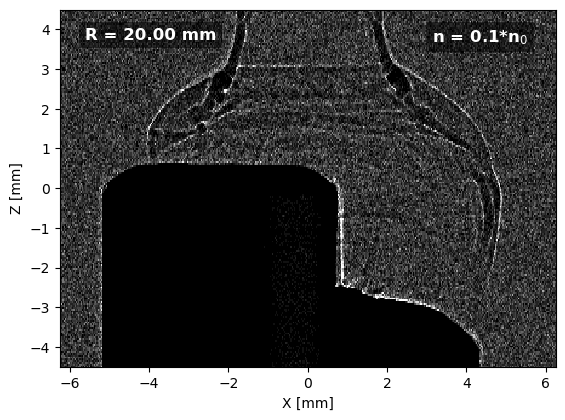

In [10]:
offset_mm = -6
output_dir = f'/home/timoney/scratch/timoney/MagShockZ/images/sh_3d_shield_dens/fp={offset_mm}'
    # get metadata and load file
metadata = {}
raytrace_metadata = ray_trace_folder + '/' + ray_trace_dir[2] + '/metadata.txt'
print(raytrace_metadata)
print(ray_trace_dir)
with open(raytrace_metadata, 'r') as f:
    metadata_lines = f.readlines()
    for line in metadata_lines:
        key, value = line.strip().split(': ')
        metadata[key] = value
ds = yt.load(metadata["flash_file"])
time_ns = ds.current_time.in_units('ns').v
ds.add_field(("flash", "edens"), function=make_electron_number_density, units="1/code_length**3",sampling_type="cell")

sim_radius = (ds.r[('flash','z')][-1]-ds.r[('flash','z')][0])/2*10 # midplane of simulation (convert to mm)
sim_radius = sim_radius.v #take out yt unit
focal_plane = sim_radius+offset_mm

rf = np.load(f"{ray_trace_folder}/{ray_trace_dir[2]}/ray_output.npy")

# vary the radius of the lens - right now, just play around with it to get max/min
# min = 5, max = 18.75
rads = np.linspace(5, 38, 15)
# for l in range(1):
lens_rad = 20
sh = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane, L=Lens_FL, R=lens_rad)
sh.solve(d1=d1,d2=d2)
sh.histogram(bin_scale=7)

fig, axs = plt.subplots()
cm = 'gray'
#clim = [0,15]

vmin=np.percentile(sh.H, 5)
vmax=np.percentile(sh.H,90)

clim=(0,vmax*3) # trial and error
sh.plot(axs, cmap=cm, clim=clim)

#add in time step to graph
axs.text(0.05, 0.95, f'R = {lens_rad:.2f} mm', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
scale = int(ray_trace_dir[2][15:])/100
axs.text(0.75, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.ylabel('Z [mm]')
plt.xlabel('X [mm]')
plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
# plt.show()
lens_rad_title=f'{lens_rad:.2f}'
if(len(lens_rad_title)) == 4:
    lens_rad_title = f'0{lens_rad_title}'
# plt.savefig(f'{output_dir}/{ray_trace_dir[i][14:]}_{lens_rad_title}mm.png')
plt.show()

In [6]:
offset_mm = -6
output_dir = f'/home/timoney/scratch/timoney/MagShockZ/images/sh_3d_shield_dens/fp={offset_mm}'
for i in range(len(ray_trace_dir)):
    # get metadata and load file
    metadata = {}
    raytrace_metadata = ray_trace_folder + '/' + ray_trace_dir[i] + '/metadata.txt'
    with open(raytrace_metadata, 'r') as f:
        metadata_lines = f.readlines()
        for line in metadata_lines:
            key, value = line.strip().split(': ')
            metadata[key] = value
    ds = yt.load(metadata["flash_file"])
    time_ns = ds.current_time.in_units('ns').v
    ds.add_field(("flash", "edens"), function=make_electron_number_density, units="1/code_length**3",sampling_type="cell")
    
    sim_radius = (ds.r[('flash','z')][-1]-ds.r[('flash','z')][0])/2*10 # midplane of simulation (convert to mm)
    sim_radius = sim_radius.v #take out yt unit
    focal_plane = sim_radius+offset_mm

    rf = np.load(f"{ray_trace_folder}/{ray_trace_dir[i]}/ray_output.npy")

    # vary the radius of the lens - right now, just play around with it to get max/min
    # min = 5, max = 18.75
    rads = np.linspace(5, 38, 15)
    for l in range(len(rads)):
    # for l in range(1):
        lens_rad = rads[l]
        sh = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane, L=Lens_FL, R=lens_rad)
        sh.solve(d1=d1,d2=d2)
        sh.histogram(bin_scale=7)
        
        fig, axs = plt.subplots()
        cm = 'gray'
        #clim = [0,15]
        
        vmin=np.percentile(sh.H, 5)
        vmax=np.percentile(sh.H,90)
    
        clim=(0,vmax*3) # trial and error
        sh.plot(axs, cmap=cm, clim=clim)
    
        #add in time step to graph
        axs.text(0.05, 0.95, f'R = {lens_rad:.2f} mm', 
             transform=axs.transAxes, 
             color='white', 
             fontsize=12, 
             fontweight='bold',
             verticalalignment='top',
             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
        scale = int(ray_trace_dir[i][15:])/100
        axs.text(0.75, 0.95, f'n = {scale}*n$_0$', 
             transform=axs.transAxes, 
             color='white', 
             fontsize=12, 
             fontweight='bold',
             verticalalignment='top',
             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
    
        plt.ylabel('Z [mm]')
        plt.xlabel('X [mm]')
        plt.ylim(-4.5, 4.5)
        plt.xlim(-6.25, 6.25)
        # plt.show()
        lens_rad_title=f'{lens_rad:.2f}'
        if(len(lens_rad_title)) == 4:
            lens_rad_title = f'0{lens_rad_title}'
        plt.savefig(f'{output_dir}/{ray_trace_dir[i][14:]}_{lens_rad_title}mm.png')
        plt.close()

yt : [INFO     ] 2026-06-05 12:06:49,925 Parameters: current_time              = 1.050017964457691e-08
yt : [INFO     ] 2026-06-05 12:06:49,926 Parameters: domain_dimensions         = [384 496 384]
yt : [INFO     ] 2026-06-05 12:06:49,928 Parameters: domain_left_edge          = [-0.8   -0.075 -0.8  ]
yt : [INFO     ] 2026-06-05 12:06:49,929 Parameters: domain_right_edge         = [0.8 2.  0.8]
yt : [INFO     ] 2026-06-05 12:06:49,930 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-06-05 12:07:09,638 Parameters: current_time              = 1.050017964457691e-08
yt : [INFO     ] 2026-06-05 12:07:09,640 Parameters: domain_dimensions         = [384 496 384]
yt : [INFO     ] 2026-06-05 12:07:09,641 Parameters: domain_left_edge          = [-0.8   -0.075 -0.8  ]
yt : [INFO     ] 2026-06-05 12:07:09,643 Parameters: domain_right_edge         = [0.8 2.  0.8]
yt : [INFO     ] 2026-06-05 12:07:09,644 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-06-05 12:07:29,451

In [6]:
# Configuration
rows, cols = 5, 15  # Your parameter dimensions
img_folder = output_dir
img_folder = f'/home/timoney/scratch/timoney/MagShockZ/images/sh_3d_shield_dens/fp=-6'
output_file = "/home/timoney/scratch/timoney/MagShockZ/images/montage/sweep_fp=-6.jpg"


def create_montage(rows, cols, folder):
    fig, axes = plt.subplots(rows, cols, figsize=(50, 16)) # Adjust figsize for wide grid
    plt.subplots_adjust(wspace=0, hspace=0)
    
    # Sort files to ensure they align with your parameter order
    # Assumes naming like 'param1_X_param2_Y.png'
    file_list = sorted(os.listdir(folder)) 
    
    for i, ax in enumerate(axes.flat):
        if i < len(file_list):
            img = Image.open(os.path.join(folder, file_list[i]))
            ax.imshow(img)
        ax.axis('off')
        
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Montage saved as {output_file}")

create_montage(rows, cols, img_folder)

NameError: name 'output_dir' is not defined

In [5]:
offsets = [0, 2, 4, 6]
for j in range(5):
    raytrace_metadata = ray_trace_folder + '/' + ray_trace_dir[j] + '/metadata.txt'
    
    output_dir = f'/home/timoney/scratch/timoney/MagShockZ/images/sh_3d_shield_dens/lower_res/{ray_trace_dir[j][14:]}'
     # get metadata and load file
    metadata = {}
    raytrace_metadata = ray_trace_folder + '/' + ray_trace_dir[j] + '/metadata.txt'
    with open(raytrace_metadata, 'r') as f:
        metadata_lines = f.readlines()
        for line in metadata_lines:
            key, value = line.strip().split(': ')
            metadata[key] = value
    ds = yt.load(metadata["flash_file"])
    time_ns = ds.current_time.in_units('ns').v
    ds.add_field(("flash", "edens"), function=make_electron_number_density, units="1/code_length**3",sampling_type="cell")
    
    sim_radius = (ds.r[('flash','z')][-1]-ds.r[('flash','z')][0])/2*10 # midplane of simulation (convert to mm)
    sim_radius = sim_radius.v #take out yt unit
    
    rf = np.load(f"{ray_trace_folder}/{ray_trace_dir[j]}/ray_output.npy")
    
    for i in range(len(offsets)):
        
        focal_plane = sim_radius-offsets[i]
    
        # vary the radius of the lens
        # min = 5, max = 18.75
        rads = np.linspace(5, 38, 10)
        for l in range(len(rads)):
            lens_rad = rads[l]
            sh = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane, L=Lens_FL, R=lens_rad)
            sh.solve(d1=d1,d2=d2)
            sh.histogram(bin_scale=7)
            
            fig, axs = plt.subplots()
            cm = 'gray'
            #clim = [0,15]
            
            vmin=np.percentile(sh.H, 5)
            vmax=np.percentile(sh.H,90)
        
            clim=(0,vmax*3) # trial and error
            sh.plot(axs, cmap=cm, clim=clim)
        
            #add in time step to graph
            axs.text(0.05, 0.95, f'R = {lens_rad:.2f} mm', 
                 transform=axs.transAxes, 
                 color='white', 
                 fontsize=12, 
                 fontweight='bold',
                 verticalalignment='top',
                 bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
            axs.text(0.75, 0.95, f'offset = {-offsets[i]}', 
                 transform=axs.transAxes, 
                 color='white', 
                 fontsize=12, 
                 fontweight='bold',
                 verticalalignment='top',
                 bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
        
            plt.ylabel('Z [mm]')
            plt.xlabel('X [mm]')
            plt.ylim(-4.5, 4.5)
            plt.xlim(-6.25, 6.25)
            # plt.show()
            lens_rad_title=f'{lens_rad:.0f}'
            if(len(lens_rad_title)) == 1:
                lens_rad_title = f'0{lens_rad_title}'
            plt.savefig(f'{output_dir}/off{offsets[i]}_R{lens_rad_title}.png')
            plt.close()

yt : [INFO     ] 2026-05-20 10:09:38,682 Parameters: current_time              = 1.050017964457691e-08
yt : [INFO     ] 2026-05-20 10:09:38,685 Parameters: domain_dimensions         = [384 496 384]
yt : [INFO     ] 2026-05-20 10:09:38,687 Parameters: domain_left_edge          = [-0.8   -0.075 -0.8  ]
yt : [INFO     ] 2026-05-20 10:09:38,688 Parameters: domain_right_edge         = [0.8 2.  0.8]
yt : [INFO     ] 2026-05-20 10:09:38,689 Parameters: cosmological_simulation   = 0


NameError: name 'Lens_Rad' is not defined

Montage saved as /home/timoney/scratch/timoney/MagShockZ/images/montage/lower_res/sweep_s100.jpg
Montage saved as /home/timoney/scratch/timoney/MagShockZ/images/montage/lower_res/sweep_s005.jpg
Montage saved as /home/timoney/scratch/timoney/MagShockZ/images/montage/lower_res/sweep_s010.jpg
Montage saved as /home/timoney/scratch/timoney/MagShockZ/images/montage/lower_res/sweep_s001.jpg
Montage saved as /home/timoney/scratch/timoney/MagShockZ/images/montage/lower_res/sweep_s050.jpg


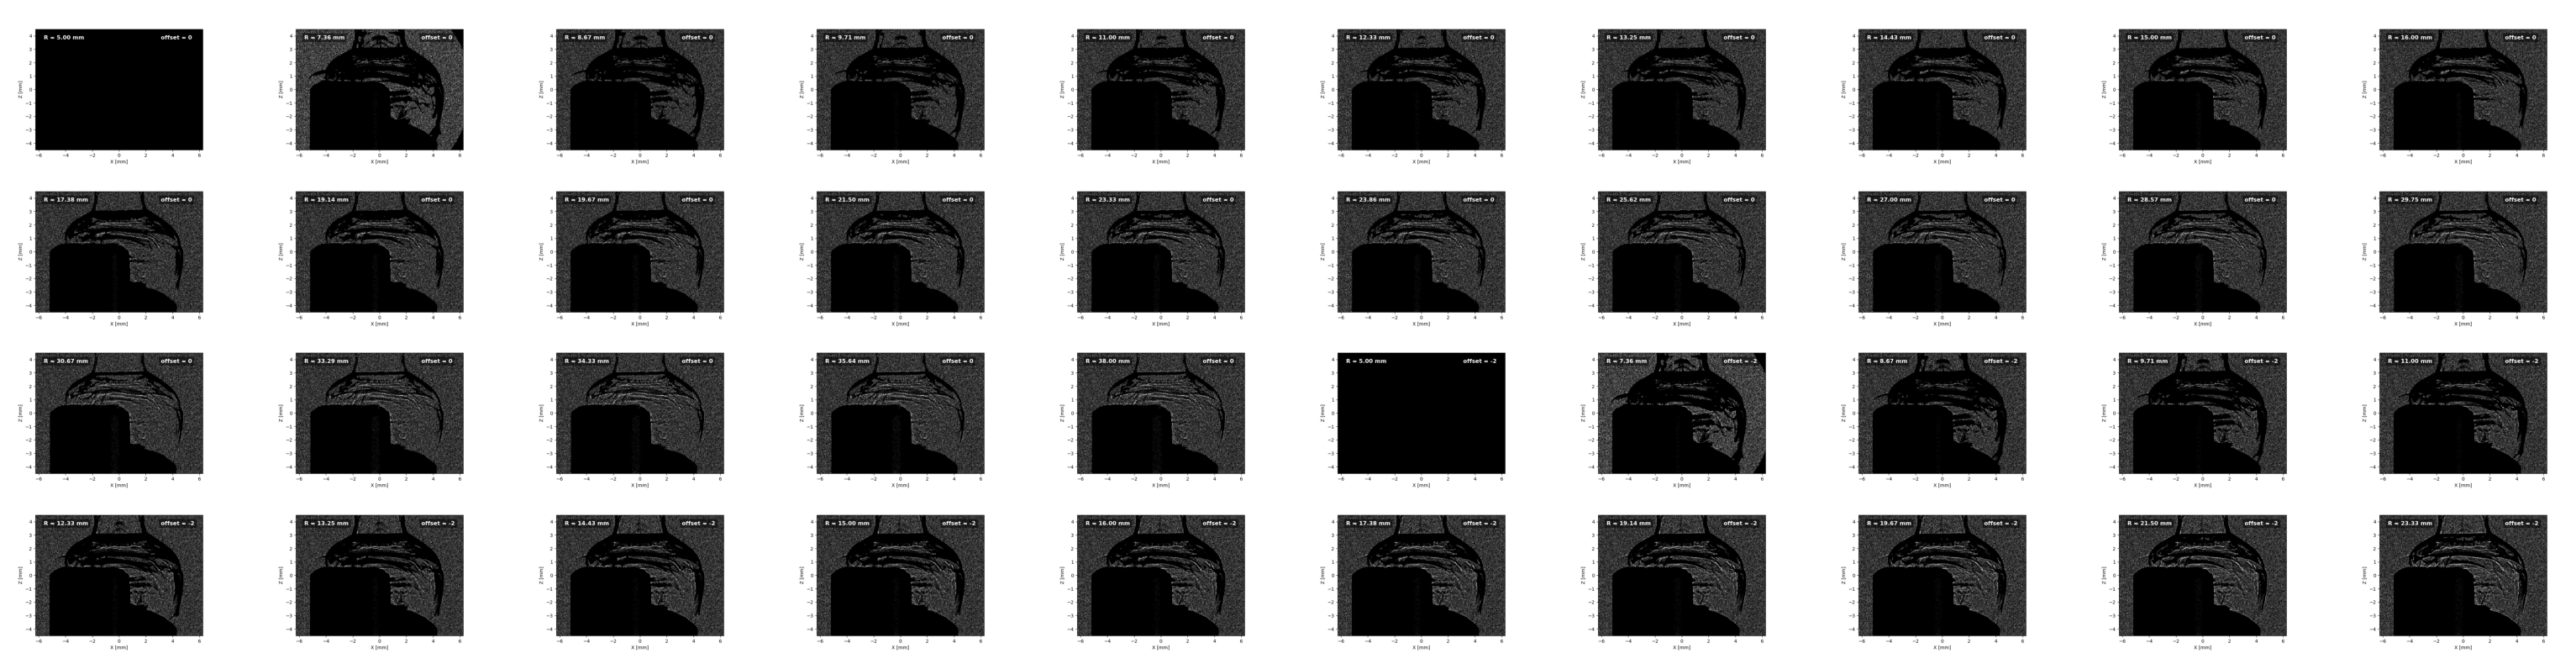

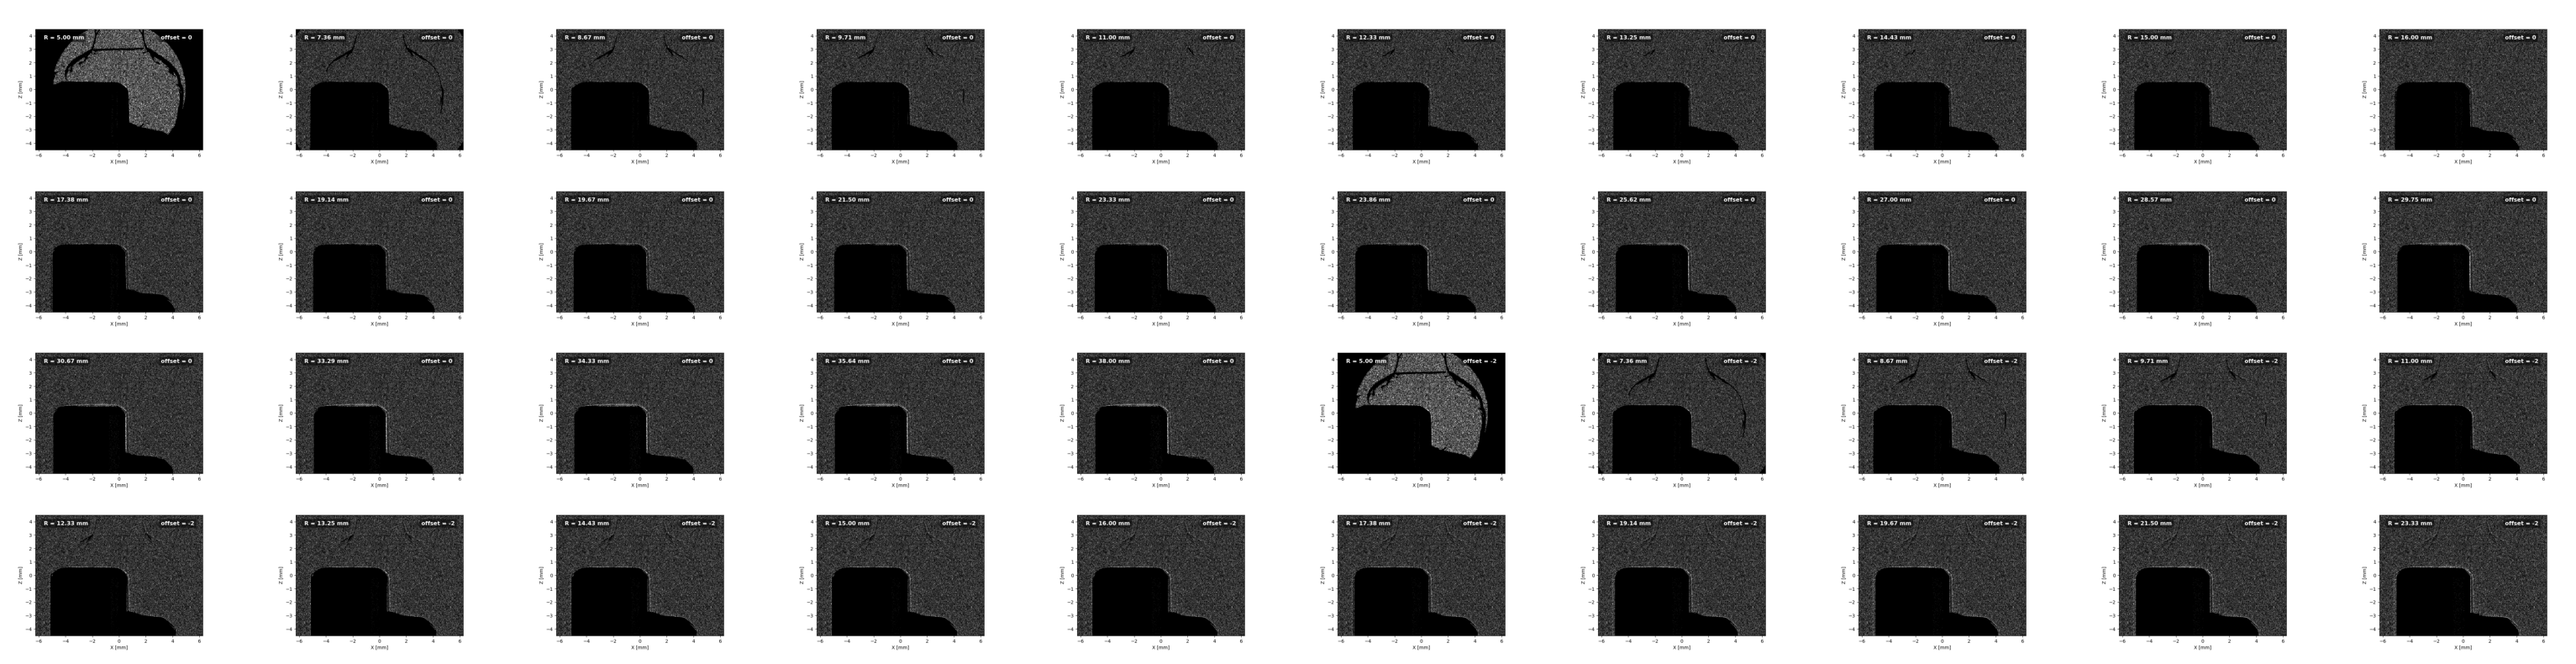

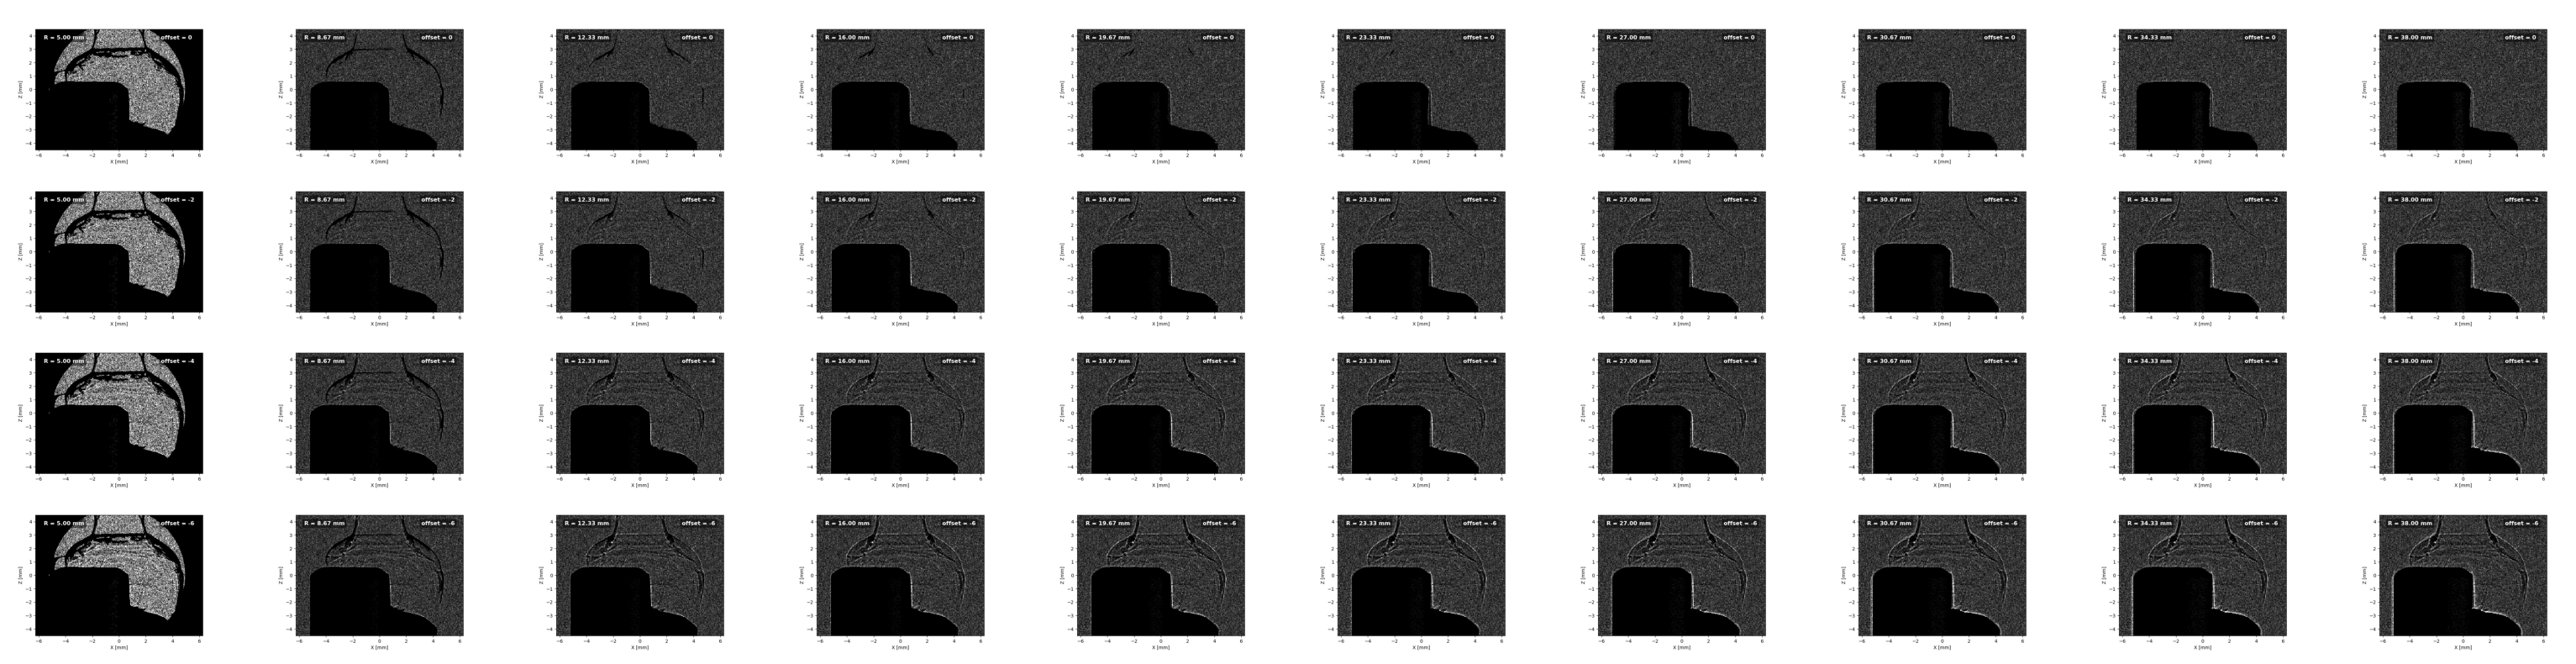

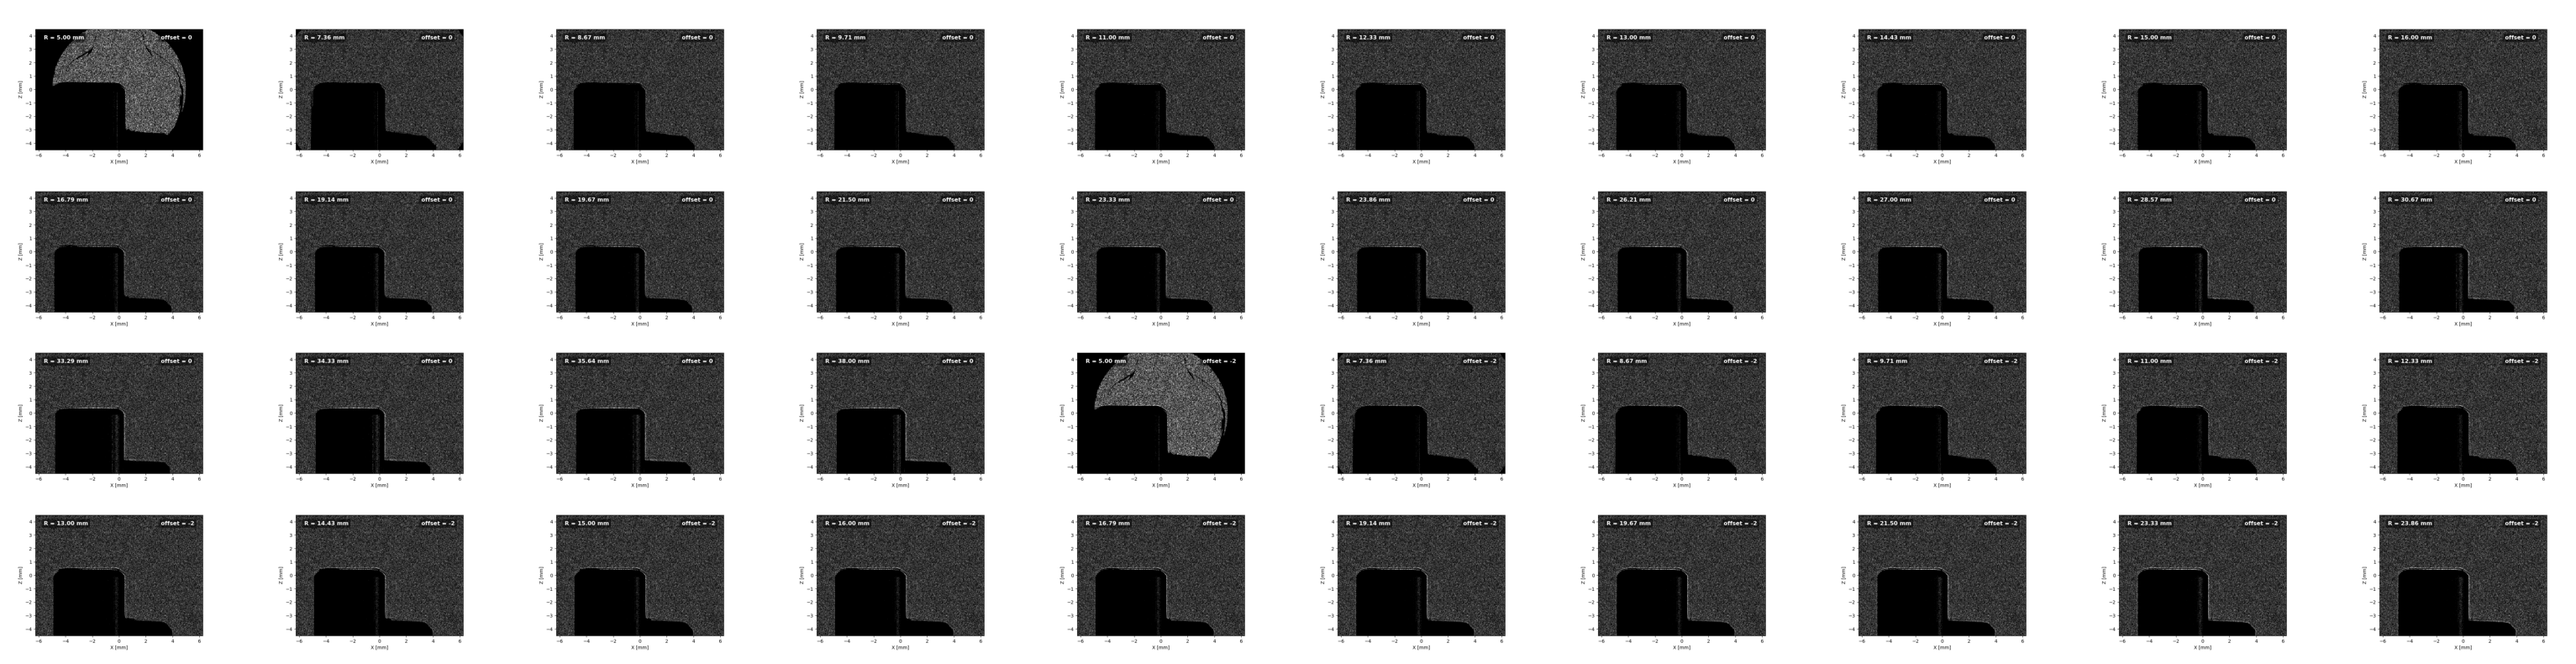

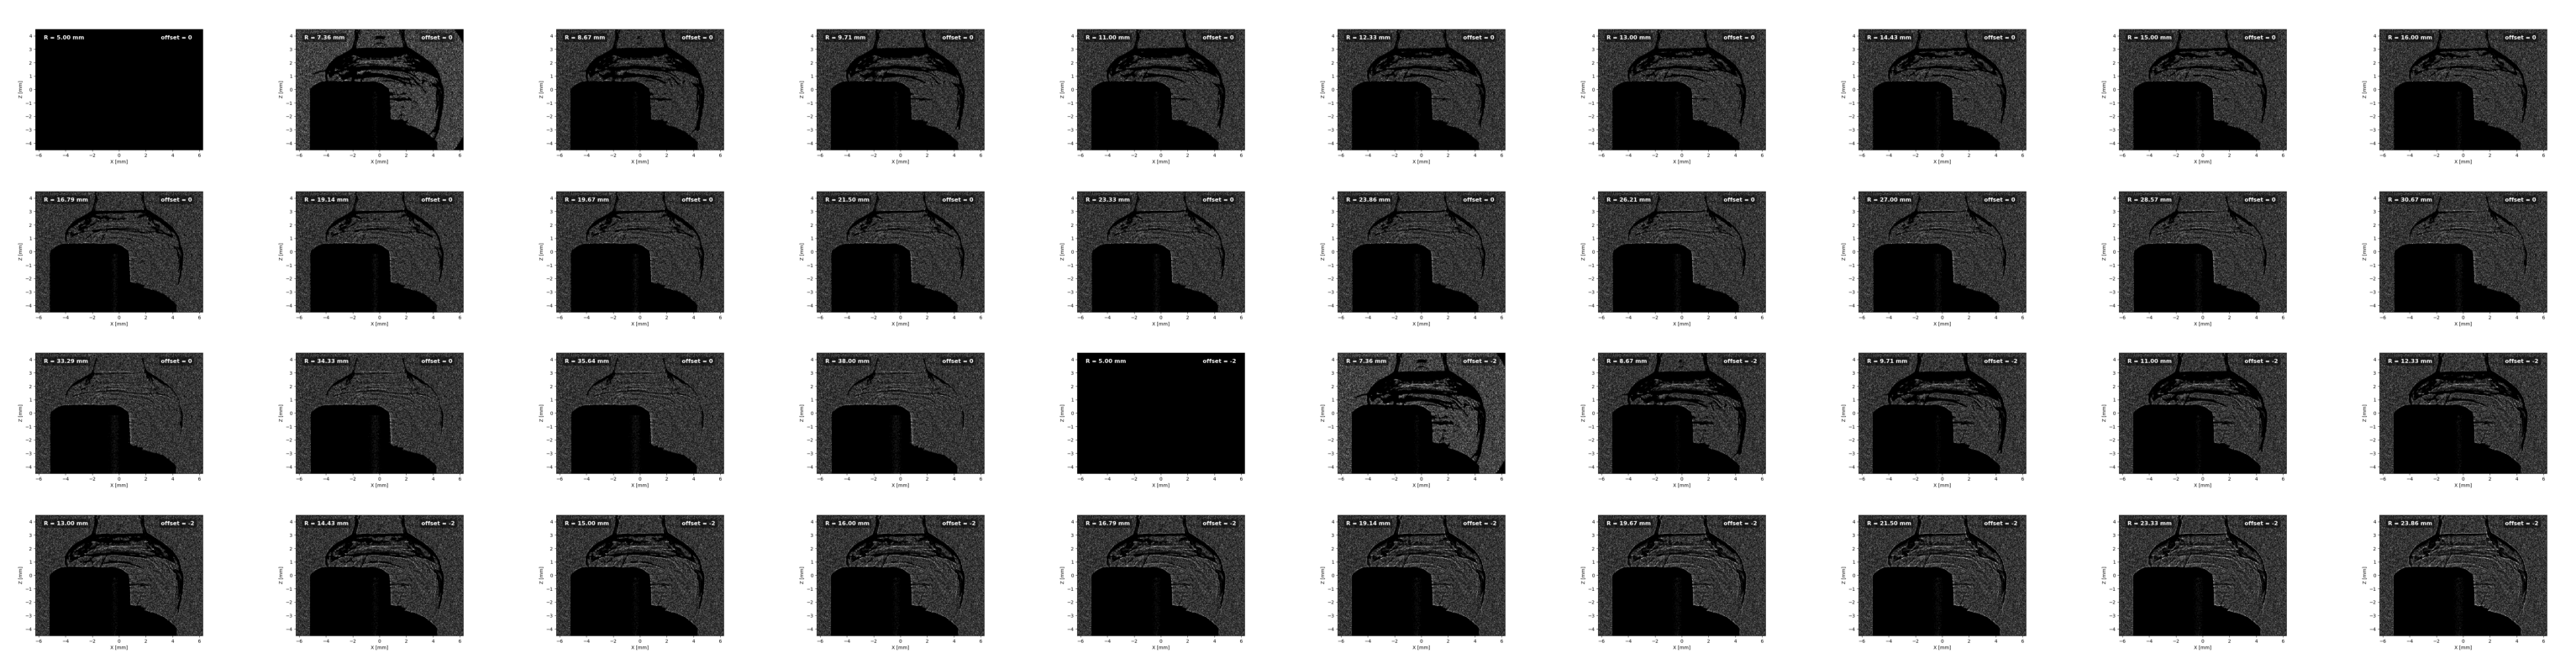

In [10]:
# Configuration

for j in range(5):
    rows, cols = 4, 10  # Your parameter dimensions
    img_folder = f'/home/timoney/scratch/timoney/MagShockZ/images/sh_3d_shield_dens/lower_res/{ray_trace_dir[j][14:]}'
    output_file = f'/home/timoney/scratch/timoney/MagShockZ/images/montage/lower_res/sweep_{ray_trace_dir[j][14:]}.jpeg'
    
    
    def create_montage(rows, cols, folder):
        fig, axes = plt.subplots(rows, cols, figsize=(40, 10)) # Adjust figsize for wide grid
        plt.subplots_adjust(wspace=0, hspace=0)
        
        # Sort files to ensure they align with your parameter order
        # Assumes naming like 'param1_X_param2_Y.png'
        file_list = sorted(os.listdir(folder)) 
        
        for i, ax in enumerate(axes.flat):
            if i < len(file_list):
                img = Image.open(os.path.join(folder, file_list[i]))
                ax.imshow(img)
            ax.axis('off')
            
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Montage saved as {output_file}")
    
    create_montage(rows, cols, img_folder)

In [12]:
offsets = [0, 2, 4, 6]
Lens_Rad = .5*75 # radius of lens

output_dir = f'/home/timoney/scratch/timoney/MagShockZ/images/sh_3d_shield_dens/bfp'
for i in range(len(ray_trace_dir)):
    # get metadata and load file
    metadata = {}
    raytrace_metadata = ray_trace_folder + '/' + ray_trace_dir[i] + '/metadata.txt'
    with open(raytrace_metadata, 'r') as f:
        metadata_lines = f.readlines()
        for line in metadata_lines:
            key, value = line.strip().split(': ')
            metadata[key] = value
    ds = yt.load(metadata["flash_file"])
    time_ns = ds.current_time.in_units('ns').v
    ds.add_field(("flash", "edens"), function=make_electron_number_density, units="1/code_length**3",sampling_type="cell")
    
    sim_radius = (ds.r[('flash','z')][-1]-ds.r[('flash','z')][0])/2*10 # midplane of simulation (convert to mm)
    sim_radius = sim_radius.v #take out yt unit

    rf = np.load(f"{ray_trace_folder}/{ray_trace_dir[i]}/ray_output.npy")

    # vary the radius of the lens - right now, just play around with it to get max/min
    # min = 5, max = 18.75
    rads = np.linspace(5, 38, 15)
    
    for l in range(len(offsets)):
        offset_mm = offsets[l]
        dist = 850
        
        sh = rtm.LIONZ_image_sweep(r0 = rf, Lx = 15, Ly = 17, focal_plane = sim_radius-offset_mm, L=Lens_FL, R=Lens_Rad) # must center grid
        sh.solve(d1=d1,d2=d2, intermed_dist = dist)
        sh.histogram(bin_scale=7)
        
        fig, axs = plt.subplots()
        cm = 'gray'
        #clim = [0,15]
        
        vmin=np.percentile(sh.H, 5)
        vmax=np.percentile(sh.H,95)
    
        clim=(0,vmax*3) # trial and error
        sh.plot(axs, cmap=cm, clim=clim)
    
        #add in time step to graph
        axs.text(0.05, 0.95, f'offset = {offset_mm} mm', 
             transform=axs.transAxes, 
             color='white', 
             fontsize=12, 
             fontweight='bold',
             verticalalignment='top',
             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
        scale = int(ray_trace_dir[i][15:])/100
        axs.text(0.75, 0.95, f'n = {scale}*n$_0$', 
             transform=axs.transAxes, 
             color='white', 
             fontsize=12, 
             fontweight='bold',
             verticalalignment='top',
             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
    
        plt.ylabel('Z [mm]')
        plt.xlabel('X [mm]')
        plt.ylim(-4.5, 4.5)
        plt.xlim(-6.25, 6.25)
        # plt.show()
        lens_rad_title=f'{lens_rad:.2f}'
        if(len(lens_rad_title)) == 4:
            lens_rad_title = f'0{lens_rad_title}'
        plt.savefig(f'{output_dir}/{ray_trace_dir[i][14:]}_off={offset_mm}mm.png')
        plt.close()

yt : [INFO     ] 2026-05-21 00:01:25,771 Parameters: current_time              = 1.050017964457691e-08
yt : [INFO     ] 2026-05-21 00:01:25,773 Parameters: domain_dimensions         = [384 496 384]
yt : [INFO     ] 2026-05-21 00:01:25,774 Parameters: domain_left_edge          = [-0.8   -0.075 -0.8  ]
yt : [INFO     ] 2026-05-21 00:01:25,775 Parameters: domain_right_edge         = [0.8 2.  0.8]
yt : [INFO     ] 2026-05-21 00:01:25,776 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-05-21 00:01:44,288 Parameters: current_time              = 1.050017964457691e-08
yt : [INFO     ] 2026-05-21 00:01:44,291 Parameters: domain_dimensions         = [384 496 384]
yt : [INFO     ] 2026-05-21 00:01:44,292 Parameters: domain_left_edge          = [-0.8   -0.075 -0.8  ]
yt : [INFO     ] 2026-05-21 00:01:44,294 Parameters: domain_right_edge         = [0.8 2.  0.8]
yt : [INFO     ] 2026-05-21 00:01:44,296 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-05-21 00:02:02,311

Montage saved as /home/timoney/scratch/timoney/MagShockZ/images/montage/bfp_95.jpeg


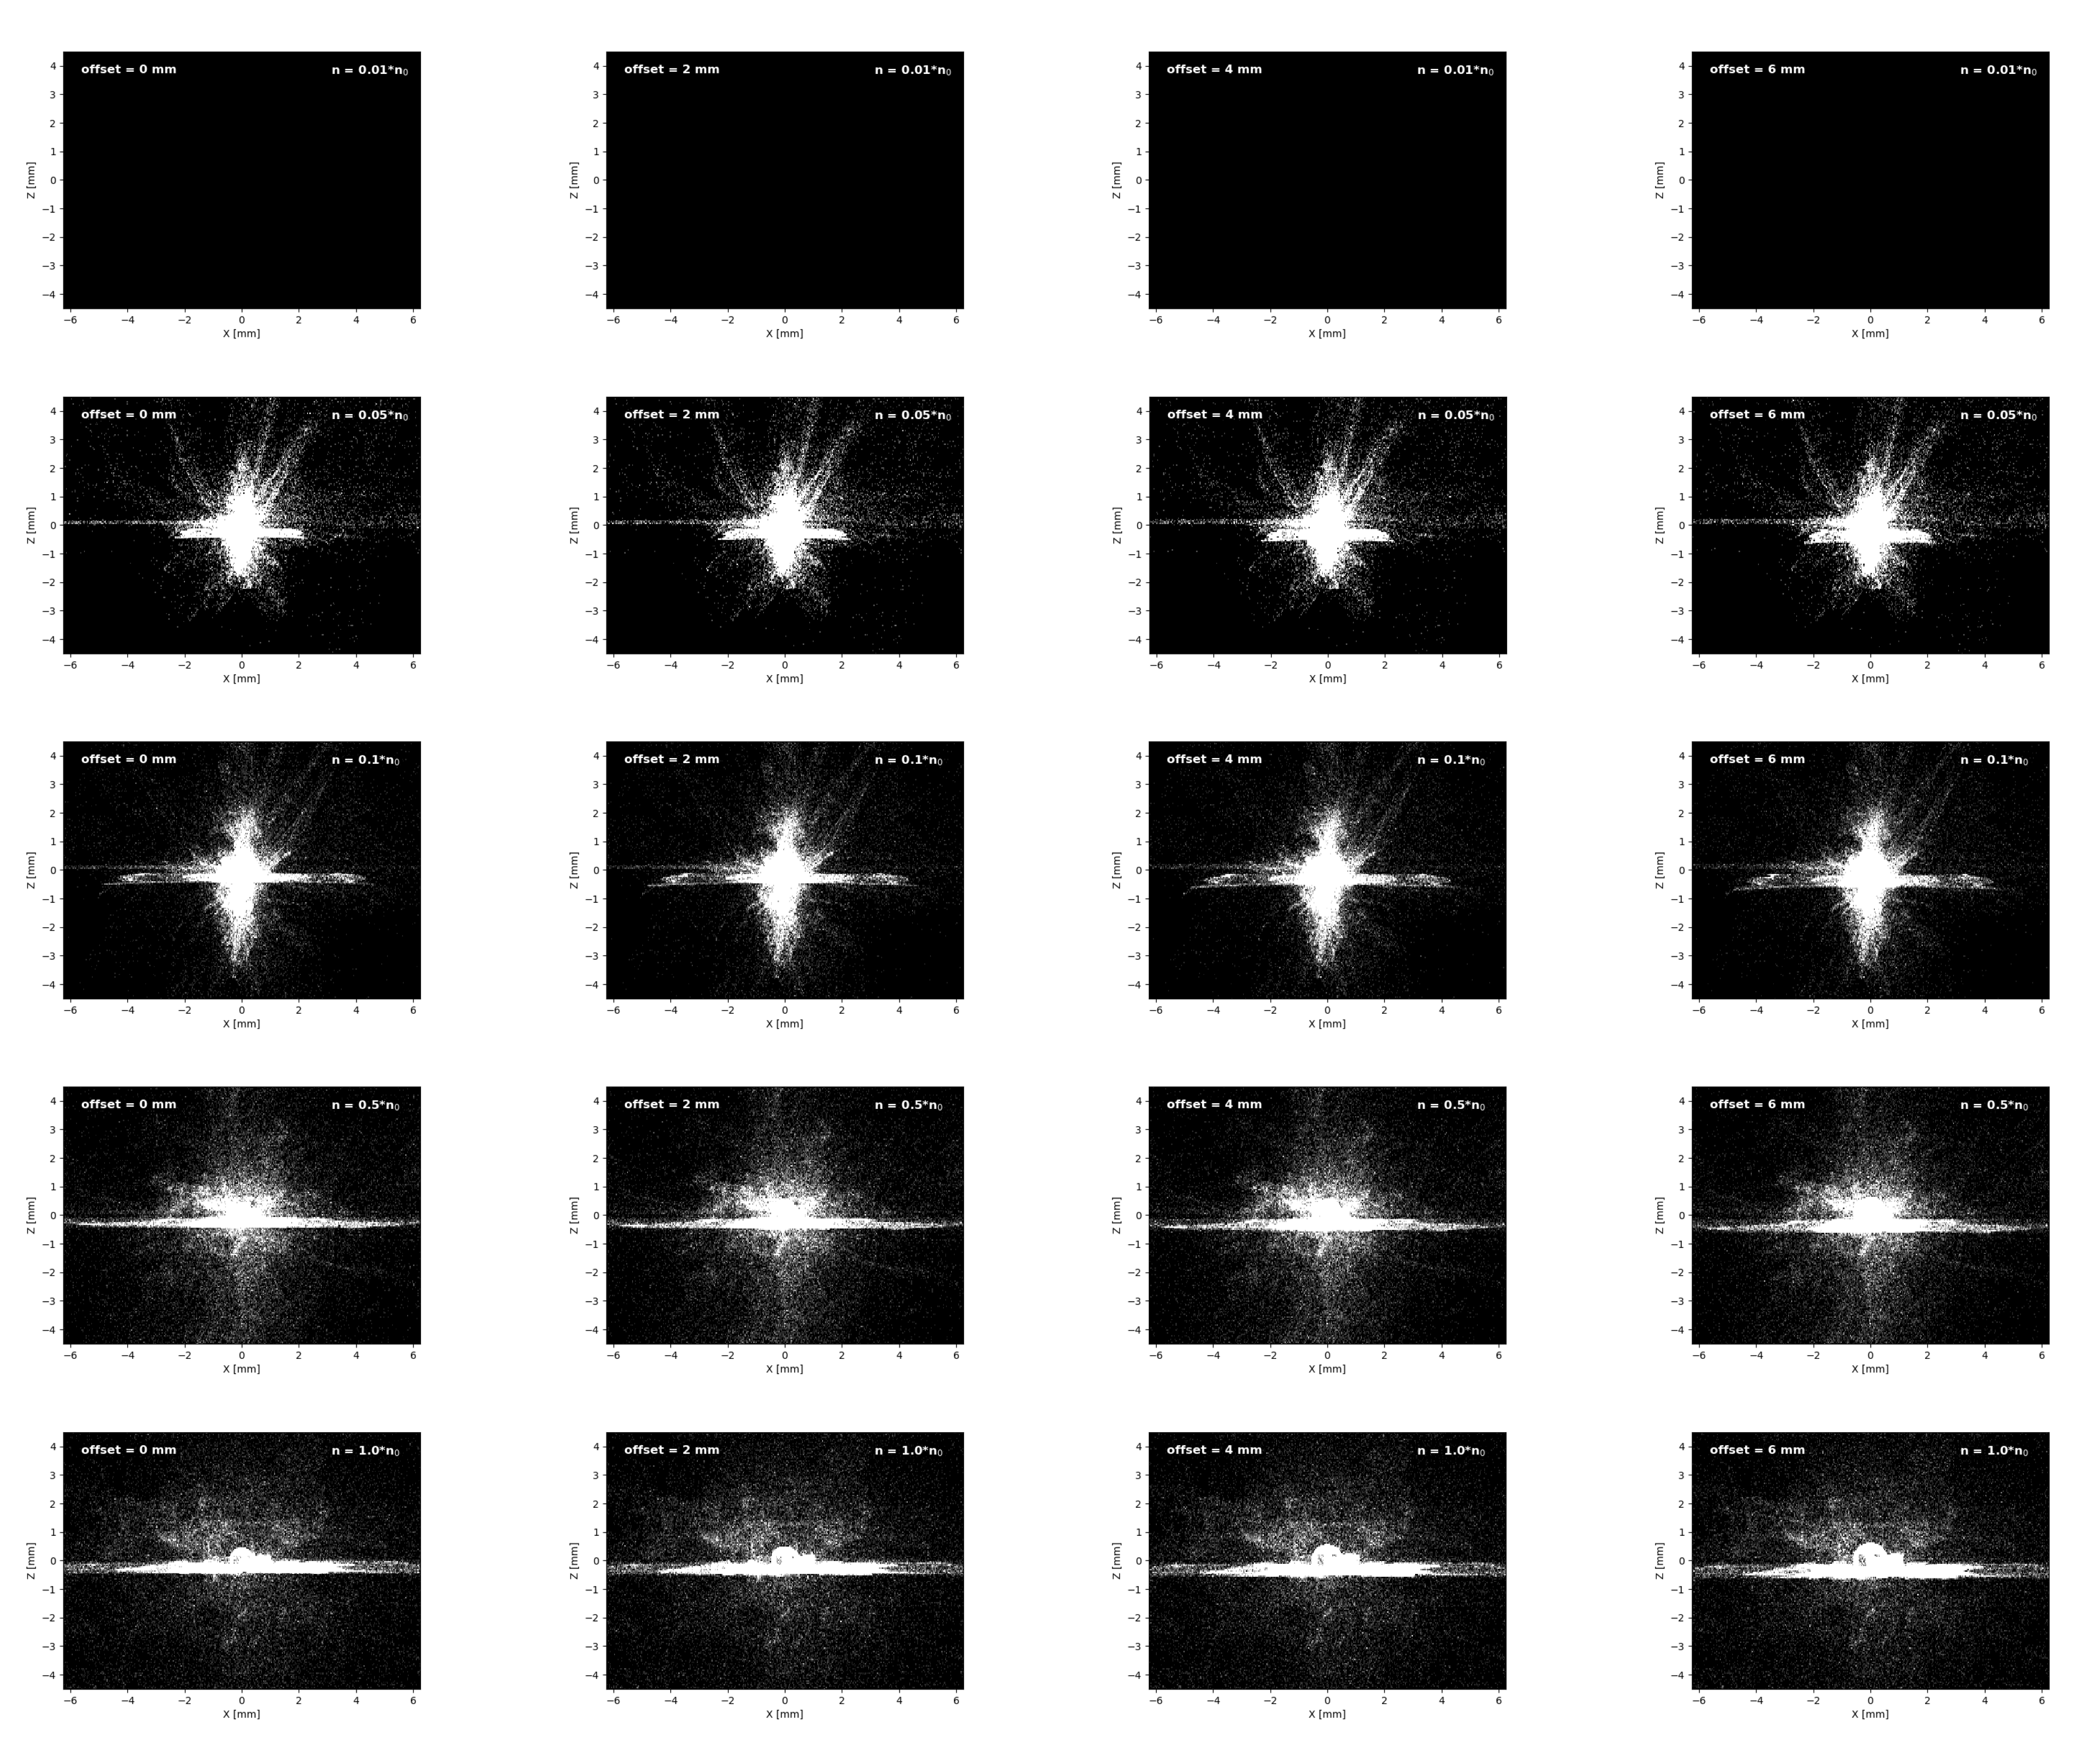

In [13]:
rows, cols = 5, 4  # Your parameter dimensions
img_folder = f'/home/timoney/scratch/timoney/MagShockZ/images/sh_3d_shield_dens/bfp'
output_file = f'/home/timoney/scratch/timoney/MagShockZ/images/montage/bfp_95.jpeg'


def create_montage(rows, cols, folder):
    fig, axes = plt.subplots(rows, cols, figsize=(50, 40)) # Adjust figsize for wide grid
    plt.subplots_adjust(wspace=0, hspace=0)
    
    # Sort files to ensure they align with your parameter order
    # Assumes naming like 'param1_X_param2_Y.png'
    file_list = sorted(os.listdir(folder)) 
    
    for i, ax in enumerate(axes.flat):
        if i < len(file_list):
            img = Image.open(os.path.join(folder, file_list[i]))
            ax.imshow(img)
        ax.axis('off')
        
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Montage saved as {output_file}")

create_montage(rows, cols, img_folder)